In [14]:
import torch
from torch import nn
print(torch.__version__)

2.10.0+cpu


In [15]:
weight = 0.7
bias = 0.3

X= torch.arange(0,10,0.1)
y = weight * X + bias
X[:10] ,y[:10]

(tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
         0.9000]),
 tensor([0.3000, 0.3700, 0.4400, 0.5100, 0.5800, 0.6500, 0.7200, 0.7900, 0.8600,
         0.9300]))

In [16]:
#Spliting the data
train_split = int(0.8* len(X))
X_train ,y_train  = X[:train_split],y[:train_split]
X_test ,y_test = X[train_split:] ,y[train_split:]

len(X_train), len(X_test),len(y_test),len(y_train)

(80, 20, 20, 80)

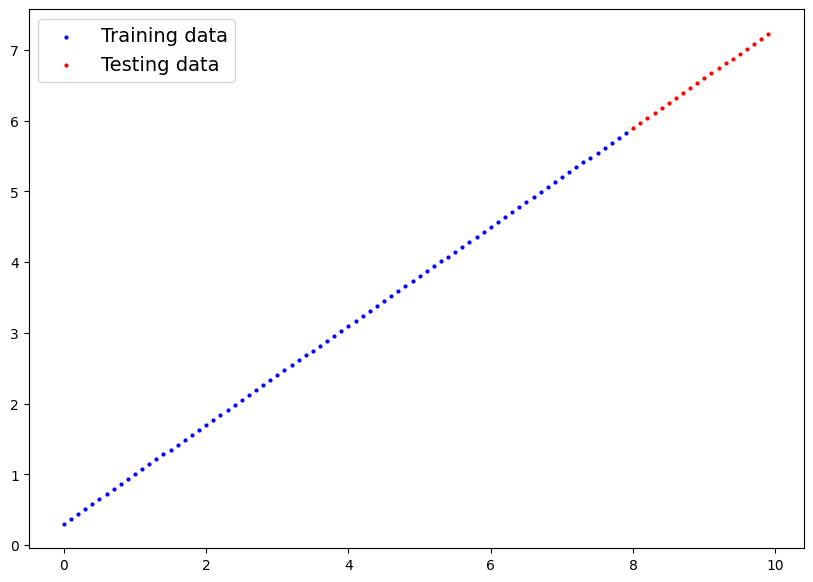

In [17]:
#Let's create a model to visualize it
import matplotlib.pyplot as plt
def plot_predictions(train_data = X_train, train_labels = y_train,test_data = X_test,test_labels=y_test, 
                     predictions=None):
    plt.figure(figsize=(10,7))
     # Plot training data in blue
    plt.scatter(train_data,train_labels,c="b",s=4,label = "Training data")
    #plot test data in green
    plt.scatter(test_data,test_labels,c="r",s=4,label = "Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label = "Predictions")
        
    plt.legend(prop={"size":14})
    
plot_predictions() 

In [20]:
class LineraRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad = True, dtype = torch.float)) # without self variable becomes local variable
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype = torch.float))
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias

In [25]:
torch.manual_seed(42)

model_0 = LineraRegression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
# List named parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
with torch.inference_mode():
    y_preds = model_0(X_test)
#torch.inference_mode() turns off a bunch of things (like gradient tracking, which is necessary for training but not for inference) to make forward-passes (data going through the forward() method) faster.

In [28]:
print(f"Number of testing sample:{len(X_test)}")
print(f"Number of predictions made:{len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing sample:20
Number of predictions made:20
Predicted values:
tensor([2.8223, 2.8560, 2.8897, 2.9233, 2.9570, 2.9907, 3.0243, 3.0580, 3.0917,
        3.1254, 3.1590, 3.1927, 3.2264, 3.2600, 3.2937, 3.3274, 3.3610, 3.3947,
        3.4284, 3.4620])


In [29]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.01)

In [32]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.08856410533189774 | MAE Test Loss: 0.08674533665180206 
Epoch: 10 | MAE Train Loss: 0.13654184341430664 | MAE Test Loss: 0.007187151815742254 
Epoch: 20 | MAE Train Loss: 0.11022557318210602 | MAE Test Loss: 0.07577633857727051 
Epoch: 30 | MAE Train Loss: 0.12885476648807526 | MAE Test Loss: 0.0478634350001812 
Epoch: 40 | MAE Train Loss: 0.13806982338428497 | MAE Test Loss: 0.03386078029870987 
Epoch: 50 | MAE Train Loss: 0.14403846859931946 | MAE Test Loss: 0.025833677500486374 
Epoch: 60 | MAE Train Loss: 0.1473228484392166 | MAE Test Loss: 0.022216249257326126 
Epoch: 70 | MAE Train Loss: 0.14986565709114075 | MAE Test Loss: 0.019545625895261765 
Epoch: 80 | MAE Train Loss: 0.151084303855896 | MAE Test Loss: 0.018295621499419212 
Epoch: 90 | MAE Train Loss: 0.15230292081832886 | MAE Test Loss: 0.01704583130776882 


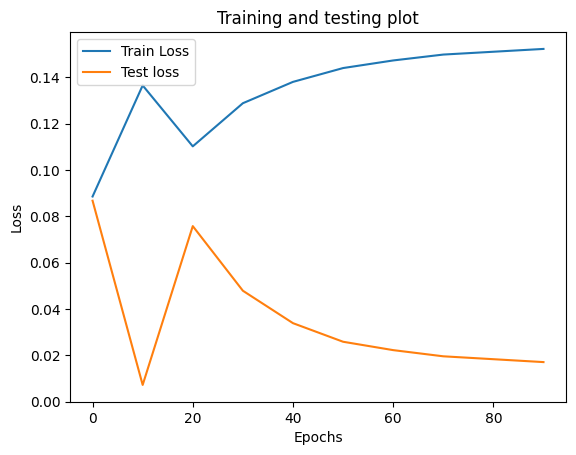

In [33]:
plt.plot(epoch_count, train_loss_values, label ="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and testing plot")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()